--2026-03-11 02:33:30--  https://raw.githubusercontent.com/am5113/ASPMI_DeepLearning/master/utilities.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4737 (4.6K) [text/plain]
Saving to: ‘utilities.py.5’

utilities.py.5      100%[===================>]   4.63K  --.-KB/s    in 0s      

2026-03-11 02:33:30 (51.5 MB/s) - ‘utilities.py.5’ saved [4737/4737]

--2026-03-11 02:33:30--  https://raw.githubusercontent.com/am5113/ASPMI_DeepLearning/master/X.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8128 (7.9K) [application/octet-s

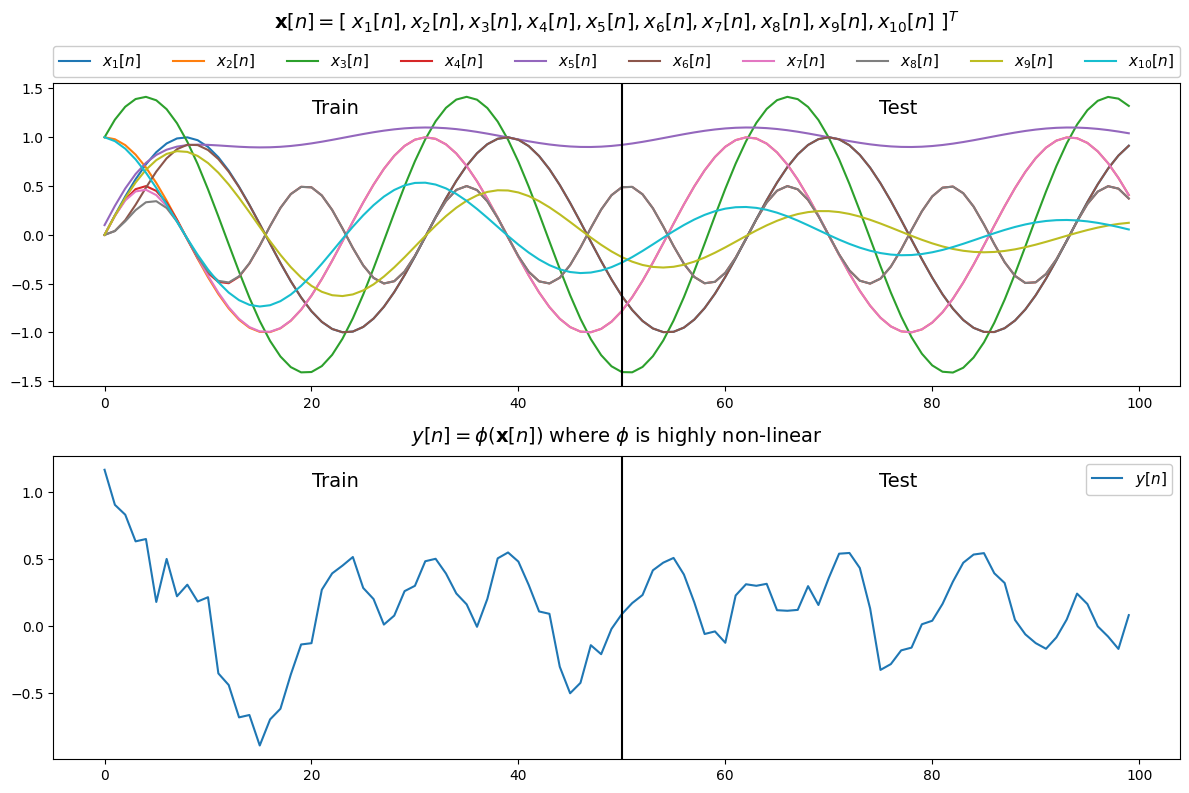

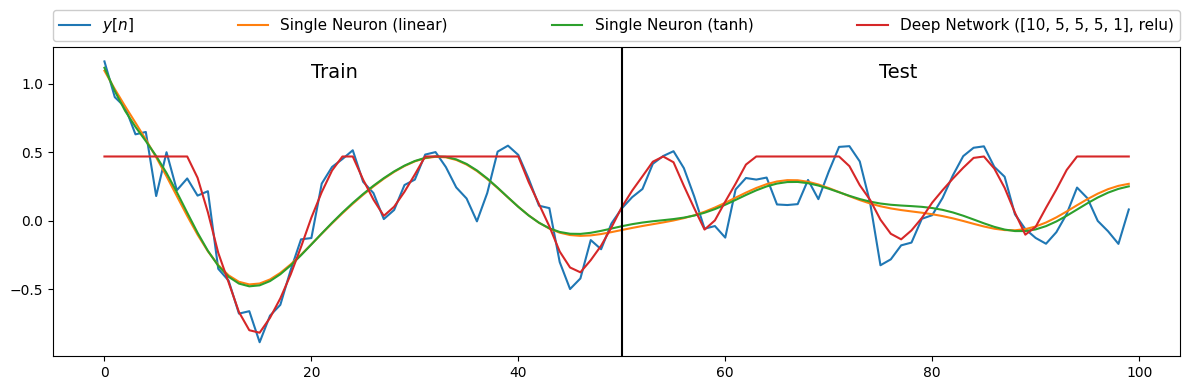

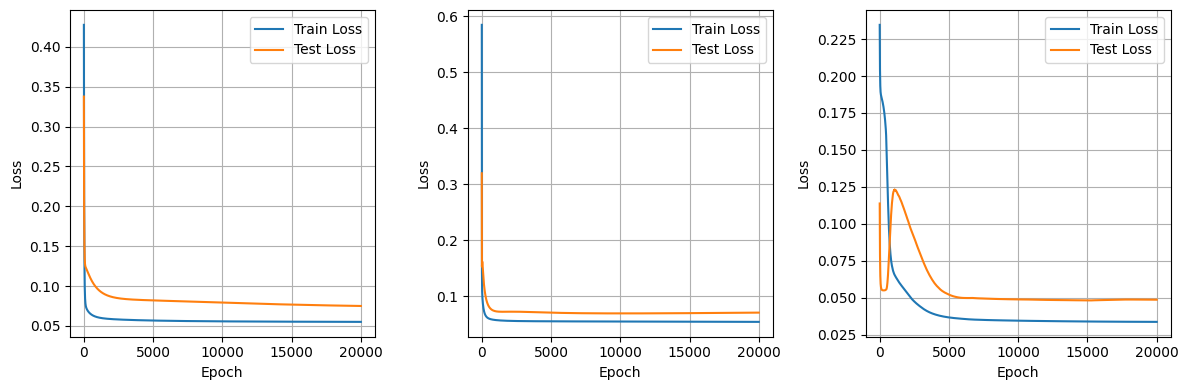

In [1]:
!wget https://raw.githubusercontent.com/am5113/ASPMI_DeepLearning/master/utilities.py
!wget https://raw.githubusercontent.com/am5113/ASPMI_DeepLearning/master/X.npy
!wget https://raw.githubusercontent.com/am5113/ASPMI_DeepLearning/master/y.npy
from utilities import *

deep_network_layers = [10,5, 5, 5,1]
epochs = 20000
learning_rate = 1e-2
noise_power = 0.01

X = np.load('X.npy')
y = np.load('y.npy')
y += np.sqrt(noise_power)*np.random.randn(y.shape[0])

plot_data(X, y)

models = [LMS(), nonlinear_LMS(), deep_network(deep_network_layers)]

loss = train_models(X, y, models, epochs, learning_rate)

plot_output(X, y, models, deep_network_layers)

import matplotlib.pyplot as plt
import numpy as np
import torch

def detach_recursive(obj):
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().item() if obj.ndim == 0 else obj.detach().cpu().numpy()
    elif isinstance(obj, (list, tuple)):
        return [detach_recursive(x) for x in obj]
    elif isinstance(obj, dict):
        return {k: detach_recursive(v) for k, v in obj.items()}
    else:
        return obj

def to_1d_numeric_array(obj):
    obj = detach_recursive(obj)

    if isinstance(obj, np.ndarray):
        return obj.astype(float).ravel()

    if isinstance(obj, (list, tuple)):
        flat = []
        for x in obj:
            x = detach_recursive(x)
            if isinstance(x, np.ndarray):
                flat.extend(x.astype(float).ravel().tolist())
            elif isinstance(x, (list, tuple)):
                flat.extend(np.array(x, dtype=float).ravel().tolist())
            else:
                flat.append(float(x))
        return np.array(flat, dtype=float)

    return np.array([float(obj)], dtype=float)

def plot_learning_curves_safe(loss):
    plt.figure(figsize=(12, 4))

    n_models = len(loss)
    for i in range(n_models):
        plt.subplot(1, n_models, i + 1)

        train_loss = to_1d_numeric_array(loss[i][0])
        test_loss  = to_1d_numeric_array(loss[i][1])

        plt.plot(train_loss, label='Train Loss')
        plt.plot(test_loss, label='Test Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves_safe(loss)